### Imports

In [1]:
from datetime import date
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Define timeframe for stock data

In [2]:
end = date.today()
start = end.replace(
    year=end.year - 5,
    day = min(end.day, 28) if end.month == 2 else end.day
)

start_date = start.strftime("%Y-%m-%d")
end_date = end.strftime("%Y-%m-%d")

### Fetch and clean stock data

In [3]:
def get_stock_data(ticker):
    data = yf.download(ticker, start_date, end_date)
    return data

df = get_stock_data("NVDA")
df.reset_index(inplace=True)
df.columns = df.columns.get_level_values(0)
df.columns.name = None
df.head()

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2021-03-23,13.037888,13.310949,12.988512,13.220926,222048000
1,2021-03-24,12.611215,13.126167,12.604981,13.118187,245840000
2,2021-03-25,12.503736,12.682786,12.241149,12.468077,295144000
3,2021-03-26,12.806972,12.823929,12.342393,12.522937,363968000
4,2021-03-29,12.915696,13.029659,12.668070,12.788018,273520000


### Plot stock data

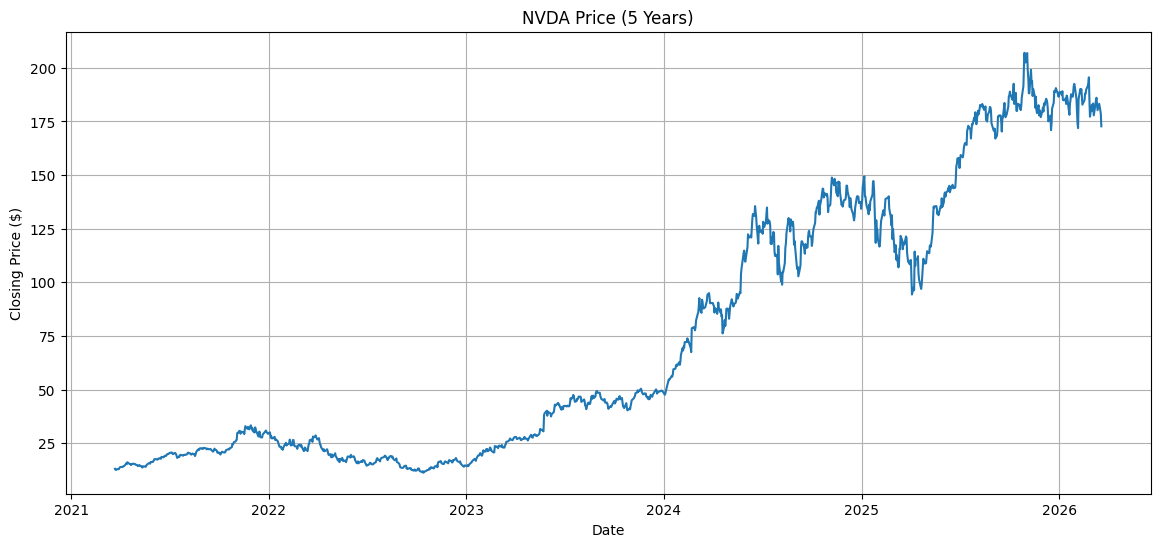

In [4]:
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.title("NVDA Price (5 Years)")
plt.show()

### Plot the 9, 21, and 100 EMAs

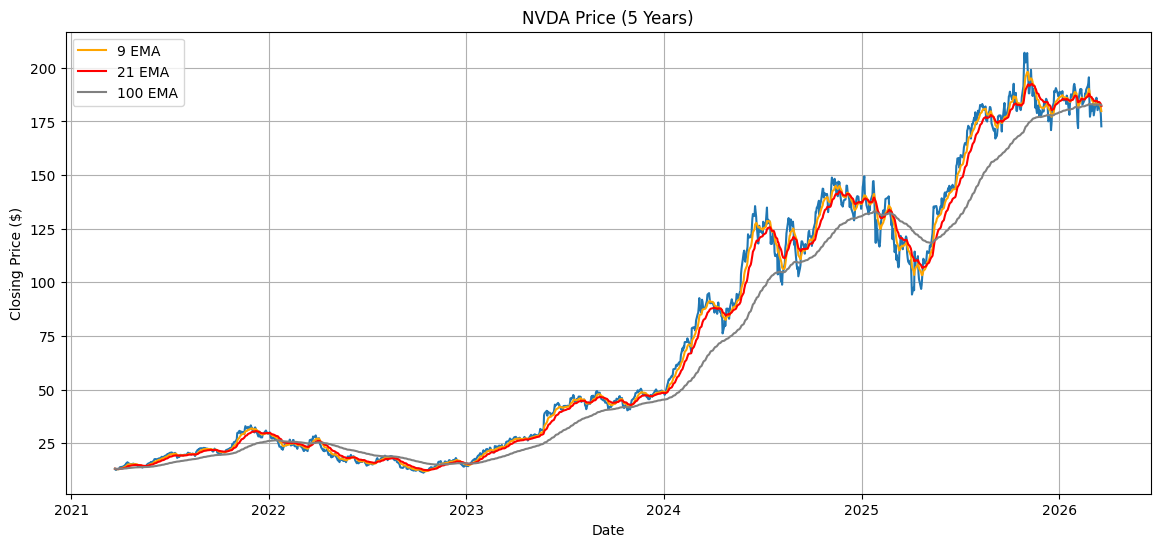

In [5]:
# Calculate EMAs
df["ema9"] = df["Close"].ewm(span=9, adjust=False).mean()
df["ema21"] = df["Close"].ewm(span=21, adjust=False).mean()
df["ema100"] = df["Close"].ewm(span=100, adjust=False).mean()

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.title("NVDA Price (5 Years)")

# Plot EMAs
plt.plot(df["Date"], df["ema9"], label="9 EMA", color="orange")
plt.plot(df["Date"], df["ema21"], label="21 EMA", color="red")
plt.plot(df["Date"], df["ema100"], label="100 EMA", color="gray")
plt.legend()

### Use an 80/20 train/test split

In [6]:
df.shape

(1255, 9)

In [7]:
split = int(len(df) * 0.8)
train = df[:split]
test = df[split:]

In [8]:
print(train.shape)
train.head()

(1004, 9)


,Date,Close,High,Low,Open,Volume,ema9,ema21,ema100
0,2021-03-23,13.037888,13.310949,12.988512,13.220926,222048000,13.037888,13.037888,13.037888
1,2021-03-24,12.611215,13.126167,12.604981,13.118187,245840000,12.952553,12.999099,13.029439
2,2021-03-25,12.503736,12.682786,12.241149,12.468077,295144000,12.862790,12.954066,13.019029
3,2021-03-26,12.806972,12.823929,12.342393,12.522937,363968000,12.851626,12.940694,13.014830
4,2021-03-29,12.915696,13.029659,12.668070,12.788018,273520000,12.864440,12.938421,13.012866


In [9]:
print(test.shape)
test.head()

(251, 9)


,Date,Close,High,Low,Open,Volume,ema9,ema21,ema100
1004,2025-03-21,117.672264,117.962197,115.392803,116.912449,266498500,117.290450,119.532424,127.400670
1005,2025-03-24,121.381401,122.191208,119.311881,119.851755,228452500,118.108640,119.700512,127.281477
1006,2025-03-25,120.661568,121.261425,118.891980,120.521601,167447200,118.619225,119.787881,127.150389
1007,2025-03-26,113.733200,118.811997,112.683444,118.702030,293463300,117.642020,119.237456,126.884702
1008,2025-03-27,111.403755,114.423041,110.633940,111.323772,236902100,116.394367,118.525301,126.578149


### Normalize the dataset

In [10]:
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler has default param feature_range=(0,1)
scaler = MinMaxScaler()

train_close = train[["Close"]]
test_close = test[["Close"]]

train_close_scaled = scaler.fit_transform(train_close)
train_close_scaled

array([[0.01321276],
       [0.0101247 ],
       [0.00934682],
       ...,
       [0.75408162],
       [0.7692045 ],
       [0.77651259]], shape=(1004, 1))

### Create training sequences

In [11]:
x_train = []
y_train = []

# For each price x, grab the 100 prices before it and add them as a singular (list) element to x_train. Add price x as an element to y_train.
for i in range(100, train_close_scaled.shape[0]):
    x_train.append(train_close_scaled[i - 100: i])
    y_train.append(train_close_scaled[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

x_train.shape

(904, 100, 1)